<a href="https://colab.research.google.com/github/andiandiandika3-prog/Mechine-Learning/blob/main/LigthGBM/Model%20Grid%2C%20random%2C%20%26%20bayesian.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Library

In [2]:
if (!require(lightgbm)) install.packages("lightgbm")
if (!require(modeldata)) install.packages("modeldata")
if (!require(dplyr)) install.packages("dplyr")
if (!require(fastDummies)) install.packages("fastDummies")
if (!require(pROC)) install.packages("pROC")
if (!require(ggplot2)) install.packages("ggplot2")
if (!require(care)) install.packages("caret")


library(lightgbm)
library(modeldata)
library(dplyr)
library(fastDummies)
library(pROC)
library(ggplot2)
library(caret)

Loading required package: lightgbm

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘lightgbm’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: modeldata

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘modeldata’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: dplyr


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: fastDummies

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘fastDummies’”
Installing package into ‘/usr/local/lib/R/site-library’

# Muat data

In [3]:
df <- read.csv("https://drive.google.com/uc?export=download&id=1uKeYEEwRSddzg9-edUsRdIHot0O5om9D")
df <- na.omit(df)
cat("------------------------------------------------------------------------------\n")
cat("Struktur Data Awal\n")
cat("------------------------------------------------------------------------------\n")
str(df)

cat("------------------------------------------------------------------------------\n")
cat("Menyesuaikan Struktur data\n")
cat("------------------------------------------------------------------------------\n")
df <- df %>%
  mutate(across(c(SEX,EDUCATION,MARRIAGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6),as.factor))
str(df)

------------------------------------------------------------------------------
Struktur Data Awal
------------------------------------------------------------------------------
'data.frame':	30000 obs. of  25 variables:
 $ ID                        : int  1 2 3 4 5 6 7 8 9 10 ...
 $ LIMIT_BAL                 : num  20000 120000 90000 50000 50000 50000 500000 100000 140000 20000 ...
 $ SEX                       : int  2 2 2 2 1 1 1 2 2 1 ...
 $ EDUCATION                 : int  2 2 2 2 2 1 1 2 3 3 ...
 $ MARRIAGE                  : int  1 2 2 1 1 2 2 2 1 2 ...
 $ AGE                       : int  24 26 34 37 57 37 29 23 28 35 ...
 $ PAY_0                     : int  2 -1 0 0 -1 0 0 0 0 -2 ...
 $ PAY_2                     : int  2 2 0 0 0 0 0 -1 0 -2 ...
 $ PAY_3                     : int  -1 0 0 0 -1 0 0 -1 2 -2 ...
 $ PAY_4                     : int  -1 0 0 0 0 0 0 0 0 -2 ...
 $ PAY_5                     : int  -2 0 0 0 0 0 0 0 0 -1 ...
 $ PAY_6                     : int  -2 2 0 0 0 0 0 -

# Mempersiapkan data

In [4]:
y <- df$default.payment.next.month
x <- df %>% select(-c(ID,default.payment.next.month))

cat("------------------------------------------------------------------------------\n")
cat("Struktur Data prediktor\n")
cat("------------------------------------------------------------------------------\n")
str(x)

------------------------------------------------------------------------------
Struktur Data prediktor
------------------------------------------------------------------------------
'data.frame':	30000 obs. of  23 variables:
 $ LIMIT_BAL: num  20000 120000 90000 50000 50000 50000 500000 100000 140000 20000 ...
 $ SEX      : Factor w/ 2 levels "1","2": 2 2 2 2 1 1 1 2 2 1 ...
 $ EDUCATION: Factor w/ 7 levels "0","1","2","3",..: 3 3 3 3 3 2 2 3 4 4 ...
 $ MARRIAGE : Factor w/ 4 levels "0","1","2","3": 2 3 3 2 2 3 3 3 2 3 ...
 $ AGE      : int  24 26 34 37 57 37 29 23 28 35 ...
 $ PAY_0    : Factor w/ 11 levels "-2","-1","0",..: 5 2 3 3 2 3 3 3 3 1 ...
 $ PAY_2    : Factor w/ 11 levels "-2","-1","0",..: 5 5 3 3 3 3 3 2 3 1 ...
 $ PAY_3    : Factor w/ 11 levels "-2","-1","0",..: 2 3 3 3 2 3 3 2 5 1 ...
 $ PAY_4    : Factor w/ 11 levels "-2","-1","0",..: 2 3 3 3 3 3 3 3 3 1 ...
 $ PAY_5    : Factor w/ 10 levels "-2","-1","0",..: 1 3 3 3 3 3 3 3 3 2 ...
 $ PAY_6    : Factor w/ 10 levels "-2"

# Paramter dasar Dan Running Model LigthGBM

| Parameter                | Macam Fungsi (Opsi)                                           | Default (R / umum) | Keterangan                    |
| ------------------------ | ------------------------------------------------------------- | ------------------ | ----------------------------- |
| boosting                 | gbdt, rf, dart                                                | gbdt               | Tipe boosting                 |
| objective                | regression, binary, multiclass, multiclassova, poisson, huber | regression         | Fungsi tujuan (loss function) |
| metric                   | rmse, mae, binary_logloss, multi_logloss, auc                 | sesuai objective   | Metrik evaluasi               |
| learning_rate            | 0 – 1                                                         | 0.1                | Learning rate                 |
| num_leaves               | 1 – ∞ (umumnya 20–150)                                        | 31                 | Jumlah leaf maksimum          |
| max_depth                | -1 (tidak dibatasi), atau >0                                  | -1                 | Kedalaman maksimum tree       |
| min_data_in_leaf         | 0 – ∞                                                         | 20                 | Minimum data per leaf         |
| min_gain_to_split        | 0 – ∞                                                         | 0                  | Minimum gain untuk split      |
| feature_fraction         | 0 – 1                                                         | 1                  | Proporsi fitur (colsample)    |
| bagging_fraction         | 0 – 1                                                         | 1                  | Proporsi data (subsample)     |
| bagging_freq             | integer ≥ 0                                                   | 0                  | Frekuensi bagging             |
| lambda_l1                | 0 – ∞                                                         | 0                  | L1 regularization             |
| lambda_l2                | 0 – ∞                                                         | 0                  | L2 regularization             |
| scale_pos_weight         | 0 – ∞                                                         | 1                  | Handling imbalance            |
| nrounds / num_iterations | integer > 0                                                   | 100                | Jumlah iterasi boosting       |
| early_stopping_round     | integer > 0                                                   | NULL               | Early stopping                |


| Opsi          | Fungsi                                                                                                    |
| ------------- | --------------------------------------------------------------------------------------------------------- |
| gbdt          | Gradient Boosting Decision Tree, default LightGBM dan paling umum digunakan.                              |
| rf            | Random Forest mode, menggunakan bagging tanpa boosting penuh.                                             |
| dart          | Dropout tree seperti XGBoost DART, mengurangi overfitting dengan menjatuhkan sebagian tree saat training. |
| regression    | Untuk target kontinu (mirip reg:squarederror di XGBoost).                                                 |
| binary        | Klasifikasi biner (output probabilitas).                                                                  |
| multiclass    | Klasifikasi multikelas dengan softmax (butuh num_class).                                                  |
| multiclassova | One-vs-all multiclass classification.                                                                     |
| poisson       | Untuk count data (misalnya jumlah kejadian).                                                              |
| huber         | Robust regression terhadap outlier.                                                                       |


In [5]:
set.seed(123)

categorical_features <- c("SEX", "EDUCATION", "MARRIAGE", "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6")

x_matrix <- as.matrix(x)

par_lgb <- list(
  objective = "binary",
  metric = "auc",
  learning_rate = 0.1,
  num_leaves = 31L,
  feature_fraction = 0.8,
  bagging_fraction = 0.8,
  bagging_freq = 1L,
  min_data_in_leaf = 20L)

dtrain <- lgb.Dataset(data = x_matrix, label = y, categorical_feature = categorical_features)
model <- lgb.train(
  params = par_lgb,
  data = dtrain,
  valids = list(train = dtrain),
  nrounds = 20,
  verbose = 1
)

[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negativ

## Fitur penting

------------------------------------------------------------------------------
Fitur penting
------------------------------------------------------------------------------
      Feature       Gain      Cover  Frequency
       <char>      <num>      <num>      <num>
 1:     PAY_0 0.32876457 0.11751606 0.03000000
 2:     PAY_2 0.29008882 0.08137721 0.02500000
 3: LIMIT_BAL 0.04856206 0.12192671 0.12666667
 4:  PAY_AMT2 0.04833275 0.08329586 0.07166667
 5: BILL_AMT1 0.03139983 0.07422616 0.08000000
 6:     PAY_4 0.02845082 0.03939770 0.01666667
 7:  PAY_AMT3 0.02217057 0.04907770 0.04333333
 8:  PAY_AMT1 0.02162883 0.06113923 0.05666667
 9:     PAY_3 0.02116391 0.05170898 0.02000000
10: BILL_AMT2 0.01938191 0.05409560 0.07333333
------------------------------------------------------------------------------
Plot Fitur penting
------------------------------------------------------------------------------


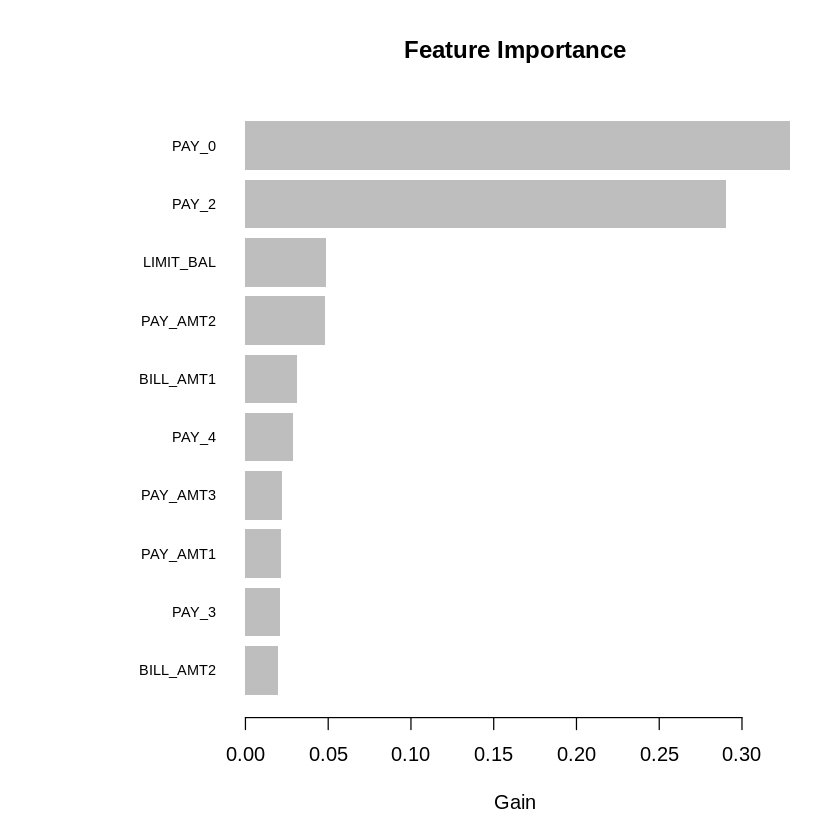

In [6]:
cat("------------------------------------------------------------------------------\n")
cat("Fitur penting\n")
cat("------------------------------------------------------------------------------\n")
imp <- lgb.importance(model, percentage = T)
print(head(imp,10))

cat("------------------------------------------------------------------------------\n")
cat("Plot Fitur penting\n")
cat("------------------------------------------------------------------------------\n")
lgb.plot.importance(imp, top_n = 10)

# Membagi menjadi data Training dan testing

In [7]:
set.seed(123)

train_index <- sample(nrow(df),0.8*nrow(df))

x_train <- x[train_index,]
y_train <- y[train_index]

x_test <- x[-train_index,]
y_test <- y[-train_index]

cat("----------------------------------------------------\n")
cat("Panjang Data train dan test\n")
cat("----------------------------------------------------\n")
cat("Panjang data ", nrow(x), "\n")
cat("Panjang train ", nrow(x_train), "\n")
cat("Panjang test ", nrow(x_test), "\n")

----------------------------------------------------
Panjang Data train dan test
----------------------------------------------------
Panjang data  30000 
Panjang train  24000 
Panjang test  6000 


## Model dengan data training dan testing

In [8]:
dtrain <- lgb.Dataset(data = as.matrix(x_train),
                      label = y_train,
                      categorical_feature = categorical_features)

model_tr <- lgb.train(
  params = par_lgb,
  data = dtrain,
  valids = list(train = dtrain),
  nrounds = 20,
  verbose = 1
)

[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negativ

## Membuat prediksi  




In [9]:
hasil <- ifelse(predict(model_tr,newdata = as.matrix(x_test))>= 0.5,1,0)

table(
  hasil = hasil,
  actual = y_test
)

auc_val <- auc(y_test, hasil)
cat(sprintf("Test AUC = %.4f\n", as.numeric(auc_val)))

     actual
hasil    0    1
    0 4512  912
    1  198  378

Setting levels: control = 0, case = 1

Setting direction: controls < cases



Test AUC = 0.6255


# hyperparameter Tunnning

## Grid Search

In [10]:
dtrain <- lgb.Dataset(
  data = x_matrix,
  label = y,
  categorical_feature = categorical_features,
  params = list(
    feature_pre_filter = FALSE
  )
)

# Parameter
grid_param <- expand.grid(
  num_leaves = c(15L, 31L),
  learning_rate = c(0.21,0.1),
  min_data_in_leaf = c(10L,20L),
  feature_fraction = c(0.7,1),
  bagging_fraction = c(0.7,1)
)

cat("----------------------------------------------------\n")
cat("Total Kombinasi : ",nrow(grid_param),"\n")
cat("----------------------------------------------------\n")

# Loop untuk mencari nilai parameter terbaik
hasil_grid <- data.frame()

for (i in seq_len(nrow(grid_param))){
  param_i <- list(
    objective = "binary",
    metric = "auc",
    num_leaves = grid_param$num_leaves[i],
    learning_rate = grid_param$learning_rate[i],
    min_data_in_leaf = grid_param$min_data_in_leaf[i],
    feature_fraction = grid_param$feature_fraction[i],
    bagging_fraction = grid_param$bagging_fraction[i],
    bagging_freq = 1L,
    verbose = -1L
  )

  cv <- lgb.cv(
    params = param_i,
    data = dtrain,
    nrounds = 100,
    nfold = 5,
    early_stopping_rounds = 10,
    verbose = 1L,
    stratified = T
  )
  best_auc <- max(unlist(cv$record_evals$valid$auc$eval))
  best_nround <- which.max(unlist(cv$record_evals$valid$auc$eval))

  hasil_grid <- rbind(hasil_grid, data.frame(
    grid_param[i,],
    best_auc = best_auc,
    best_nround = best_nround
  ))

  cat(sprintf("[%d/%d] AUC = %.4f | Lr = %.2f | leaves = %d\n",
              i, nrow(grid_param), best_auc,
              grid_param$learning_rate[i],grid_param$num_leaves[i]))
}

----------------------------------------------------
Total Kombinasi :  32 
----------------------------------------------------
[1/32] AUC = 0.7798 | Lr = 0.21 | leaves = 15
[2/32] AUC = 0.7789 | Lr = 0.21 | leaves = 31
[3/32] AUC = 0.7842 | Lr = 0.10 | leaves = 15
[4/32] AUC = 0.7819 | Lr = 0.10 | leaves = 31
[5/32] AUC = 0.7819 | Lr = 0.21 | leaves = 15
[6/32] AUC = 0.7771 | Lr = 0.21 | leaves = 31
[7/32] AUC = 0.7837 | Lr = 0.10 | leaves = 15
[8/32] AUC = 0.7814 | Lr = 0.10 | leaves = 31
[9/32] AUC = 0.7804 | Lr = 0.21 | leaves = 15
[10/32] AUC = 0.7783 | Lr = 0.21 | leaves = 31
[11/32] AUC = 0.7834 | Lr = 0.10 | leaves = 15
[12/32] AUC = 0.7810 | Lr = 0.10 | leaves = 31
[13/32] AUC = 0.7800 | Lr = 0.21 | leaves = 15
[14/32] AUC = 0.7803 | Lr = 0.21 | leaves = 31
[15/32] AUC = 0.7831 | Lr = 0.10 | leaves = 15
[16/32] AUC = 0.7817 | Lr = 0.10 | leaves = 31
[17/32] AUC = 0.7826 | Lr = 0.21 | leaves = 15
[18/32] AUC = 0.7785 | Lr = 0.21 | leaves = 31
[19/32] AUC = 0.7840 | Lr = 0.10 |

## Ambil best grid model

In [11]:
cat("----------------------------------------------------\n")
cat("Kombinasi Terbaik \n")
cat("----------------------------------------------------\n")
print(hasil_grid[which.max(hasil_grid$best_auc),])


best_param_grid <- list(
  objective = "binary",
  metric = "auc",
  num_leaves = grid_param$num_leaves[which.max(hasil_grid$best_auc)],
  learning_rate = grid_param$learning_rate[which.max(hasil_grid$best_auc)],
  min_data_in_leaf = grid_param$min_data_in_leaf[which.max(hasil_grid$best_auc)],
  feature_fraction = grid_param$feature_fraction[which.max(hasil_grid$best_auc)],
  bagging_fraction = grid_param$bagging_fraction[which.max(hasil_grid$best_auc)],
  bagging_freq = 1L,
  verbose = -1L
)

model_grid <- lgb.train(
  params = best_param_grid,
  data = dtrain,
  nrounds = hasil_grid$best_nround[which.max(hasil_grid$best_auc)]
)

pred_grid <- ifelse(predict(model_grid,newdata = as.matrix(x_test))>=0.5,1,0)

cat("----------------------------------------------------\n")
cat("Confusion Matrix \n")
cat("----------------------------------------------------\n")
table(pred_grid, y_test)

----------------------------------------------------
Kombinasi Terbaik 
----------------------------------------------------
  num_leaves learning_rate min_data_in_leaf feature_fraction bagging_fraction
3         15           0.1               10              0.7              0.7
   best_auc best_nround
3 0.7841786          65
----------------------------------------------------
Confusion Matrix 
----------------------------------------------------


         y_test
pred_grid    0    1
        0 4491  804
        1  219  486

## Random Search

In [16]:
set.seed(42)
n <- 30

hasil_random <- data.frame()

# Loopin random search
for ( i in seq_len(n)){
  param_i <- list(
    objective      ="binary",
    metric         = "auc",
    num_leaves     = sample(10:64,1),
    learning_rate  = runif(1, 0.01, 0.4),
    min_data_in_leaf = sample(5:50, 1),
    feature_fraction = runif(1, 0.5, 1),
    bagging_fraction = runif(1, 0.5, 1),
    bagging_freq   = 1L,
    lambda_l1       = runif(1, 0, 2),
    lambda_l2       = runif(1, 0, 2),
    verbosity      = -1L
  )

  cv <- lgb.cv(
    params = param_i,
    data = dtrain,
    nrounds = 200,
    nfold = 5,
    early_stopping_rounds = 15,
    verbose = -1L,
    stratified = T
  )

  best_auc <- max(unlist(cv$record_evals$valid$auc))
  best_nround <- which.max(unlist(cv$record_evals$valid$auc))

  hasil_random <- rbind(hasil_random, data.frame(
    num_leaves = param_i$num_leaves,
    learning_rate = param_i$learning_rate,
    min_data_in_leaf = param_i$min_data_in_leaf,
    feature_fraction = param_i$feature_fraction,
    bagging_fraction = param_i$bagging_fraction,
    lambda_l1 = param_i$lambda_l1,
    lambda_l2 = param_i$lambda_l2,
    best_auc = best_auc,
    best_nround = best_nround
  ))

  cat(sprintf("[%d/%d] AUC = %.4f | lr = %.3f | leaves = %d\n",
              i, n, best_auc, param_i$learning_rate, param_i$num_leaves))

}

[1/30] AUC = 0.7742 | lr = 0.375 | leaves = 58
[2/30] AUC = 0.7767 | lr = 0.228 | leaves = 61
[3/30] AUC = 0.7791 | lr = 0.199 | leaves = 62
[4/30] AUC = 0.7819 | lr = 0.271 | leaves = 15
[5/30] AUC = 0.7764 | lr = 0.354 | leaves = 44
[6/30] AUC = 0.7715 | lr = 0.399 | leaves = 54
[7/30] AUC = 0.7820 | lr = 0.110 | leaves = 41
[8/30] AUC = 0.7811 | lr = 0.216 | leaves = 21
[9/30] AUC = 0.7789 | lr = 0.204 | leaves = 35
[10/30] AUC = 0.7812 | lr = 0.178 | leaves = 35
[11/30] AUC = 0.7842 | lr = 0.084 | leaves = 19
[12/30] AUC = 0.7828 | lr = 0.291 | leaves = 11
[13/30] AUC = 0.7801 | lr = 0.099 | leaves = 58
[14/30] AUC = 0.7845 | lr = 0.021 | leaves = 59
[15/30] AUC = 0.7848 | lr = 0.026 | leaves = 27
[16/30] AUC = 0.7824 | lr = 0.092 | leaves = 49
[17/30] AUC = 0.7783 | lr = 0.212 | leaves = 58
[18/30] AUC = 0.7773 | lr = 0.324 | leaves = 35
[19/30] AUC = 0.7781 | lr = 0.308 | leaves = 30
[20/30] AUC = 0.7762 | lr = 0.386 | leaves = 62
[21/30] AUC = 0.7808 | lr = 0.121 | leaves = 42
[

### Best Parameter random search

In [18]:
cat("-------------------------------\n")
cat("Best parameter Random Search\n")
cat("-------------------------------\n")

best_r <- hasil_random[which.max(hasil_random$best_auc), ]
print(best_r, digits = 3)

best_param_random <- list(
  objective = "binary",
  metric = "auc",
  num_leaves = best_r$num_leaves,
  learning_rate = best_r$learning_rate,
  min_data_in_leaf = best_r$min_data_in_leaf,
  feature_fraction = best_r$feature_fraction,
  bagging_fraction = best_r$bagging_fraction,
  bagging_freq = 1L,
  lambda_l1 = best_r$lambda_l1,
  lambda_l2 = best_r$lambda_l2,
  verbosity = -1L
)

model_random <- lgb.train(
  params = best_param_random,
  data = dtrain,
  nrounds = best_r$best_nround
)

pred_prob_random <- predict(model_random, as.matrix(x_test))
pred_random <- ifelse(pred_prob_random >= 0.5, 1, 0)

cat("\nTest AUC Random Search:\n")
cat(sprintf("%.4f\n", as.numeric(auc(y_test, pred_prob_random))))

cat("\nConfusion Matrix\n")
table(hasil = pred_random, aktual = y_test)

-------------------------------
Best parameter Random Search
-------------------------------
        num_leaves learning_rate min_data_in_leaf feature_fraction
eval156         35        0.0303               39            0.802
        bagging_fraction lambda_l1 lambda_l2 best_auc best_nround
eval156            0.917     0.945     0.802    0.785         156

Test AUC Random Search:


Setting levels: control = 0, case = 1

Setting direction: controls < cases



0.8253

Confusion Matrix


     aktual
hasil    0    1
    0 4505  792
    1  205  498

## Bayesian Optimization

In [24]:
if (!require(mlrMBO)) install.packages("mlrMBO")
if (!require(ParamHelpers)) install.packages("ParamHelpers")
if (!require(smoof)) install.packages("smoof")
if (!require(lhs)) install.packages("lhs")
if (!require(rgenoud)) install.packages("rgenoud")

library(mlrMBO)
library(ParamHelpers)
library(smoof)
library(lhs)
library(rgenoud)

Loading required package: DiceKriging

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘DiceKriging’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘DiceKriging’


The following object is masked from ‘package:checkmate’:

    checkNames




### Membuat ruang parameter dan membuat fungsi bayesian

In [29]:
par_set <- makeParamSet(
  makeNumericParam("learning_rate", lower = 0.01, upper = 0.3),
  makeIntegerParam("num_leaves", lower = 10L, upper = 64L),
  makeIntegerParam("min_data_in_leaf", lower = 5L, upper = 50L),
  makeNumericParam("feature_fraction", lower = 0.5, upper = 1),
  makeNumericParam("bagging_fraction", lower = 0.5, upper = 1),
  makeNumericParam("lambda_l1", lower = 0, upper = 2),
  makeNumericParam("lambda_l2", lower = 0, upper = 2)
)

obj_fun <- makeSingleObjectiveFunction(
  name = "lgb_auc",
  fn = function(x){
    param <- list(
      objective     = "binary",
      metric        = "auc",
      learning_rate = x["learning_rate"],
      num_leaves    = as.integer(x["num_leaves"]),
      min_data_in_leaf = as.integer(x["min_data_in_leaf"]),
      feature_fraction = x["feature_fraction"],
      bagging_fraction = x["bagging_fraction"],
      bagging_freq = 1L,
      lambda_l1    = x["lambda_l1"],
      lambda_l2    = x["lambda_l2"],
      verbosity    = -1L
    )

     cv <- lgb.cv(
      params = param,
      data = dtrain,
      nrounds = 200,
      nfold = 5,
      early_stopping_rounds = 15,
      verbose = -1L,
      stratified = TRUE
    )
    max(unlist(cv$record_evals$valid$auc$eval))
  },
  par.set = par_set,
  minimize = FALSE
)



### Jalankan Bayesian optimization

In [30]:
set.seed(42)

ctrl <- makeMBOControl()
ctrl <- setMBOControlTermination(ctrl, iters = 20)
ctrl <- setMBOControlInfill(ctrl, crit = makeMBOInfillCritEI(), opt.restarts = 3)

design <- generateDesign(n = 10, par.set = par_set, fun = lhs::randomLHS)

cat("Memulai Bayesian Optimization...\n")
hasil_bayes <- mbo(
  fun = obj_fun,
  design = design,
  control = ctrl,
  show.info = TRUE
)

Memulai Bayesian Optimization...


Computing y column(s) for design. Not provided.

[mbo] 0: learning_rate=0.214; num_leaves=49; min_data_in_leaf=24; feature_fraction=0.724; bagging_fraction=0.61; lambda_l1=0.944; lambda_l2=1 : y = 0.778 : 1.3 secs : initdesign

[mbo] 0: learning_rate=0.0789; num_leaves=29; min_data_in_leaf=9; feature_fraction=0.829; bagging_fraction=0.508; lambda_l1=1.47; lambda_l2=1.93 : y = 0.784 : 2.5 secs : initdesign

[mbo] 0: learning_rate=0.177; num_leaves=13; min_data_in_leaf=33; feature_fraction=0.854; bagging_fraction=0.704; lambda_l1=1.66; lambda_l2=1.33 : y = 0.784 : 3.6 secs : initdesign

[mbo] 0: learning_rate=0.126; num_leaves=33; min_data_in_leaf=46; feature_fraction=0.646; bagging_fraction=0.587; lambda_l1=0.0666; lambda_l2=0.703 : y = 0.781 : 1.5 secs : initdesign

[mbo] 0: learning_rate=0.264; num_leaves=57; min_data_in_leaf=30; feature_fraction=0.961; bagging_fraction=0.961; lambda_l1=0.278; lambda_l2=0.188 : y = 0.778 : 1.3 secs : initdesign

[mbo] 0: learning_rate=0.299; num_leave

### hasil bayesian

In [31]:
cat("============================================\n")
cat("Hasil Parameter Bayesian Optimization\n")
cat("============================================\n")
print(hasil_bayes$x, digits = 3)

cat("============================================\n")
cat("Hasil AUC Bayesian Optimization\n")
cat("============================================\n")
print(hasil_bayes$y, digits = 3)

Hasil Parameter Bayesian Optimization
$learning_rate
[1] 0.0374

$num_leaves
[1] 19

$min_data_in_leaf
[1] 21

$feature_fraction
[1] 0.78

$bagging_fraction
[1] 0.997

$lambda_l1
[1] 0.968

$lambda_l2
[1] 1.98

Hasil AUC Bayesian Optimization
[1] 0.786


### Training model bayesian

In [35]:
best_param_bayes <- list(
  objective = "binary",
  metric = "auc",
  learning_rate = hasil_bayes$x$learning_rate,
  num_leaves = as.integer(hasil_bayes$x$num_leaves),
  min_data_in_leaf = as.integer(hasil_bayes$x$min_data_in_leaf),
  feature_fraction = hasil_bayes$x$feature_fraction,
  bagging_fraction = hasil_bayes$x$bagging_fraction,
  bagging_freq = 1L,
  lambda_l1 = hasil_bayes$x$lambda_l1,
  lambda_l2 = hasil_bayes$x$lambda_l2,
  verbosity = -1L
)

cv_final <- lgb.cv(
  params = best_param_bayes,
  data = dtrain,
  nrounds = 200,
  nfold = 5,
  early_stopping_rounds = 15,
  verbose = -1L,
  stratified = TRUE
)

opt_nrounds <- which.max(unlist(cv_final$record_evals$valid$auc$eval))

model_bayes <- lgb.train(
  params = best_param_bayes,
  data = dtrain,
  nrounds = opt_nrounds
)

pred_prob_bayes <- predict(model_bayes, newdata = as.matrix(x_test))
hasil <- factor(ifelse(pred_prob_bayes >= 0.5, 1, 0), levels = c("0", "1"))
y_test_factor <- factor(y_test, levels = c("0", "1"))

confusionMatrix(hasil, y_test_factor)

Confusion Matrix and Statistics

          Reference
Prediction    0    1
         0 4503  808
         1  207  482
                                          
               Accuracy : 0.8308          
                 95% CI : (0.8211, 0.8402)
    No Information Rate : 0.785           
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.3968          
                                          
 Mcnemar's Test P-Value : < 2.2e-16       
                                          
            Sensitivity : 0.9561          
            Specificity : 0.3736          
         Pos Pred Value : 0.8479          
         Neg Pred Value : 0.6996          
             Prevalence : 0.7850          
         Detection Rate : 0.7505          
   Detection Prevalence : 0.8852          
      Balanced Accuracy : 0.6648          
                                          
       'Positive' Class : 0               
                        